# Diciplina de Machine Learning - Pós-Graduação PUC-RIO
### MVP apresentado como atividade final da Sprint de Machine Learning

Criação de modelo de Machine Learning destinado à classificação de pacientes com suspeita de diabetes.

Objetivo: Redução da necessidade de avaliação clínica, diminuindo o número de consultas, o que proporciona maior comodidade aos pacientes e a redução de custos à rede hospitalar, uma vez que o paciente, após a análise automatizada dos resultados dos exames laboratoriais, possa ser encaminhado diretamente à clpinica especializada, sem a necessidade de revisão por parte do clínico geral.

<a href="https://colab.research.google.com/github/rogerioferreira/MVP-Machine_Learnin-PUC-RIO/blob/main/notebooks/ml-03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importação das bibliotecas necessárias para o projeto

In [137]:
# importação de bibliotecas básicas
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# importação de métodos de tratamento
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA

# importação de modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# importação de ensembles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier


# configuração para não exibir os warnings
warnings.filterwarnings("ignore")

# definição da semente aleatória visando a reprodutibilidade
SEED = 42

## Coleta, análise e tratamento dos dados

In [138]:
# Fonte: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset


data_path = "../dados/diabetes_prediction_dataset.csv"
url = "https://raw.githubusercontent.com/rogerioferreira/MVP-Machine_Learnin-PUC-RIO/refs/heads/main/dados/diabetes_prediction_dataset.csv"

if os.path.exists(data_path):
    # caraga do dataset localmente, caso presente
    df = pd.read_csv(data_path)
else:
    # caraga do dataset diretamente pelo Git Hub
    df = pd.read_csv(url)

In [139]:
# verificação da presença de valores nulos
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [140]:
# verificação da presença de dados duplicados
df.duplicated().any()

np.True_

In [141]:
# verificação da quantidade de entradas duplicadas no dataframe
df.duplicated().sum()

np.int64(3854)

In [142]:
# remoção de entradas duplicadas
# reinicialização do indez para evitar geração da valores NaN
df = df.drop_duplicates().reset_index(drop=True)

In [147]:
# realização da transformação de variáveis categóricas e padronização / mormalização das variáveis numéricas

# Instanciando o encoder OneHot para as variáveis categóricas
# handle_unknown='ignore' evita erro se uma categoria nova aparecer no futuro
# sparse_output=False retorna uma matriz densa ao invés de esparsa
features = ["gender", "smoking_history"]
one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")

one_hot_features = one_hot.fit_transform(df[features])
df_one_hot = pd.DataFrame(
    one_hot_features,
    columns=one_hot.get_feature_names_out(features),
)
df.drop(columns=features, inplace=True)
df = pd.concat([df_one_hot, df], axis=1)
del df_one_hot


# Instanciando o StandardScaler / Normalizer para as variáveis numéricas não binárias
features = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
scaler = Normalizer()

scaled_features = scaler.fit_transform(df[features])
df_scaled = pd.DataFrame(
    scaled_features,
    columns=scaler.get_feature_names_out(features),
)
df.drop(columns=features, inplace=True)  # exclusão das colunas não normalizadas
df = pd.concat([df_scaled, df], axis=1)
del df_scaled


# conversão das features binárias de int64 para float64
df[["hypertension", "heart_disease"]] = df[["hypertension", "heart_disease"]].astype(
    "float64"
)

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96146 entries, 0 to 96145
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          96146 non-null  float64
 1   bmi                          96146 non-null  float64
 2   HbA1c_level                  96146 non-null  float64
 3   blood_glucose_level          96146 non-null  float64
 4   gender_Male                  96146 non-null  float64
 5   gender_Other                 96146 non-null  float64
 6   smoking_history_current      96146 non-null  float64
 7   smoking_history_ever         96146 non-null  float64
 8   smoking_history_former       96146 non-null  float64
 9   smoking_history_never        96146 non-null  float64
 10  smoking_history_not current  96146 non-null  float64
 11  hypertension                 96146 non-null  float64
 12  heart_disease                96146 non-null  float64
 13  diabetes        

In [129]:
# Separação em bases de treino e teste (holdout)
X = df.drop(columns="diabetes")
y = df["diabetes"]

In [ ]:
# aplicação de ténica de redução de dimensionalidade
pca = PCA(n_components=0.95, random_state=SEED)  # n_components=0.95 mantém 95% da variância    
X_pca = pca.fit_transform(X)

X_pca.shape

(96146, 8)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.20, random_state=SEED
)  # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 5  # número de folds da validação cruzada (3, 5, 10)
kfold = KFold(
    n_splits=num_particoes, shuffle=True, random_state=SEED
)  # faz o particionamento em K folds

## Seleção prévia dos modelos

KNeighbors     :  0.9143 0.0010
DecisionTree   :  0.8798 0.0015
GaussianNB     :  0.8545 0.0032
SVM            :  0.9124 0.0013
AdaBoost       :  0.9120 0.0012
RandomForest   :  0.9118 0.0019
ExtraTrees     :  0.9008 0.0025


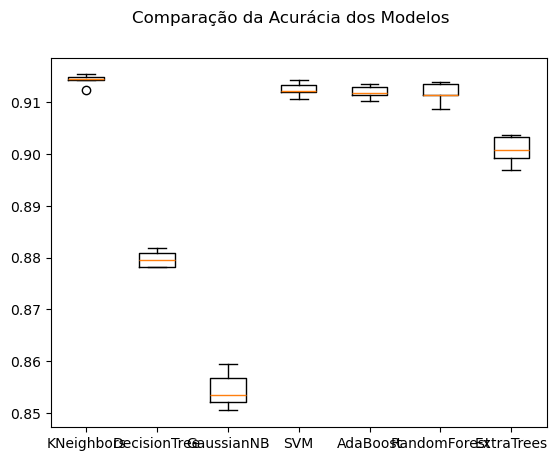

In [ ]:
# pré-seleção dos modelos

# criação de listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# definição dos modelos para teste
models.append(("KNeighbors", KNeighborsClassifier()))
models.append(("DecisionTree", DecisionTreeClassifier()))
models.append(("GaussianNB", GaussianNB()))
models.append(("SVM", SVC()))
models.append(("AdaBoost", AdaBoostClassifier()))
models.append(("RandomForest", RandomForestClassifier()))
models.append(("ExtraTrees", ExtraTreesClassifier()))


# métricas mais relevantes para seleção dos modelos:
# Acurácia (accuracy): A proporção de predições corretas sobre o total de predições.
# Precisão (precision): Dos casos que o modelo previu como positivos, quantos eram realmente positivos.
# Sensibilidade (recall): Dos casos que eram realmente positivos, quantos o modelo conseguiu identificar.
# Pontuação F1 (f1-score): É a média harmônica entre precisão e recall. É uma métrica útil quando as classes estão desbalanceadas.
# Curva ROC e AUC: Medem a capacidade do modelo de distinguir entre as classes.
for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy")

    results.append(cv_results)
    names.append(name)

    msg = f"{name:<13}: média: {cv_results.mean():>8.4f} desvio: {cv_results.std():>8.4f}"  # média e desvio padrão dos K resultados da validação cruzada

    print(msg)

# boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle("Comparação da Acurácia dos Modelos")
ax = fig.add_subplot(1, 1, 1)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

## Otimização dos modelos selecionados